**K-Means Clustering**

This notebook captures the seminar activity for unit 6 where k-means clustering was performed on the iris.csv data set.  

The data was examined, categorical columns excluded and NaN / infinite values procesed before undertaking K-Means Clustring.  Various k values were used, however  k = 3 was determined to be the most appropriate as we can see that there are 3 species of iris in the dataset and we are examining potential differences in petal and sepal size between these.  

The notebook below contains the coding for the above task with text covering logic behind the steps undertaken, observations, reflections and conclusions.  

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd

%matplotlib inline

In [ ]:
df = pd.read_csv('Unit06 iris.csv')

In [ ]:
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Drop catagorical column 'species'

In [ ]:
df = df.drop('species', axis=1)

Normalise the data set

In [ ]:
from sklearn.preprocessing import StandardScaler
X = df.values[:,1:]
X = np.nan_to_num(X)
Clus_dataSet = StandardScaler().fit_transform(X)


In [ ]:
from sklearn.cluster import KMeans
clusterNum = 3
k_means = KMeans(init = "k-means++", n_clusters = clusterNum, n_init = 12)
k_means.fit(X)
labels = k_means.labels_
print(labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 0 2 2 2 2
 2 2 2 2 2 2 2 2 0 2 2 2 0 2 2 0 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2
 2 2]


Species was dropped earlier as it was a categorical value, but now we need to compare the assigned cluster to the species. Should instead have kept the species column and excluded the values for this (last) column.




In [ ]:
df['cluster_km'] = labels
display(df.head())

,sepal_length,sepal_width,petal_length,petal_width,cluster_km
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


### Reloading data and re-running clustering to compare with original species

In [ ]:

df = pd.read_csv('Unit06 iris.csv')

# Prepare the features (excluding 'species') for clustering
X = df.iloc[:, :-1].values  # All columns except the last one (species)
X =  np.nan_to_num(X)

# Standardize the data
scaler = StandardScaler()
Clus_dataSet = scaler.fit_transform(X)

# Apply KMeans clustering
k_means = KMeans(init = "k-means++", n_clusters = 3, n_init = 12)
k_means.fit(Clus_dataSet)
labels = k_means.labels_

# Add the cluster labels back to the original DataFrame
df['cluster_km'] = labels

display(df.head())

,sepal_length,sepal_width,petal_length,petal_width,species,cluster_km
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


Compare labels with species by cross-tabulation

In [ ]:

comparison_table = pd.crosstab(df_original['species'], df_original['cluster_km'])
display(comparison_table)

cluster_km,0,1,2
species,,,
setosa,0,50,0
versicolor,11,0,39
virginica,36,0,14


The results suggest that with three clusters, the setosa species forms a clear distinct cluster (1).  versicolor and viginica do not form such distict clusters and overlap is seen, however majority of viginica are in cluster 0 and versicolor are in cluster 2.

Plot the sum of squared errors to investigate optimal value for k

In [ ]:
sse = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, init= "k-means++",n_init= 12,max_iter= 300)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

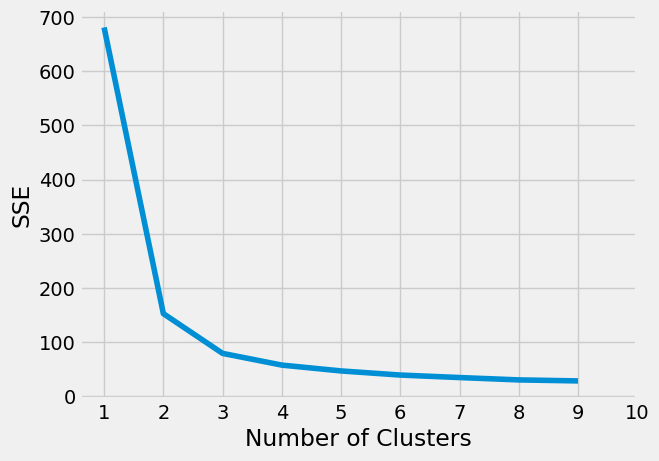

In [ ]:
plt.style.use("fivethirtyeight")
plt.plot(range(1, 10), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

SSE suggests k=2 or k=3 would be optimal.  In thia dataset however we already have the knowledge that there are 3 different species, so k=3 would be used in order to see if we can seperate these based on sepal and petal size.

Further investigate this with a silhouette analysis (to practice generating this graph)

In [ ]:
from sklearn.metrics import silhouette_score, silhouette_samples

silhouette_coefficients = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, init= "k-means++",n_init= 12,max_iter= 300)
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_coefficients.append(score)

silhouette_coefficients

[np.float64(0.6808136202936816),
 np.float64(0.5525919445499757),
 np.float64(0.4978256901095472),
 np.float64(0.4885175508886279),
 np.float64(0.36820569682713084),
 np.float64(0.3559677254550641),
 np.float64(0.3521090401515315),
 np.float64(0.3464376485899385)]

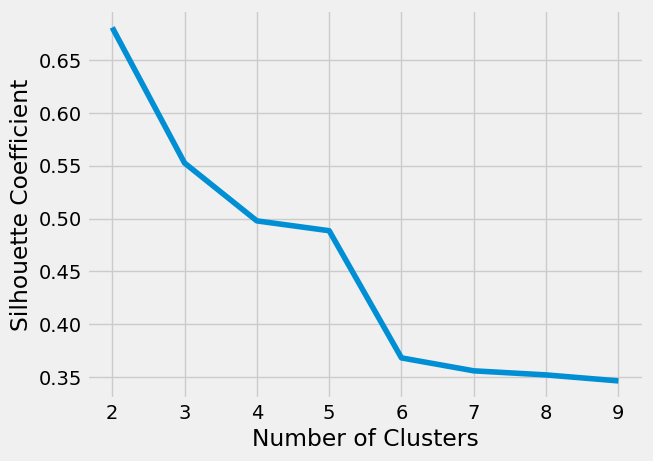

In [ ]:
plt.style.use("fivethirtyeight")
plt.plot(range(2, 10), silhouette_coefficients)
plt.xticks(range(2, 10))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

### Visualizing the clusters based on petal size



In [ ]:
import seaborn as sns

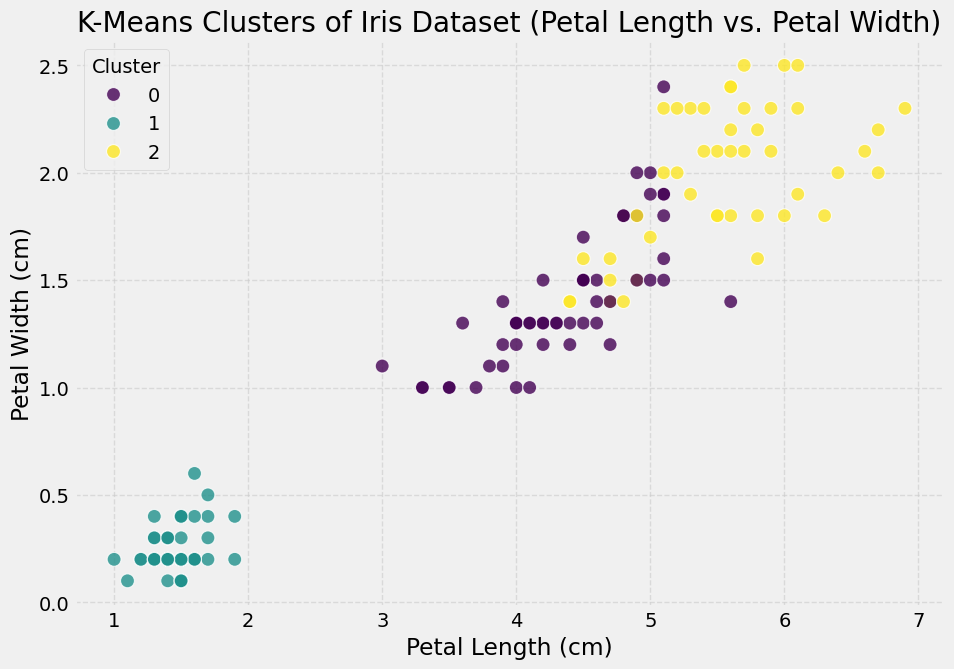

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='petal_length',
    y='petal_width',
    hue='cluster_km',
    data=df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('K-Means Clusters of Iris Dataset (Petal Length vs. Petal Width)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Based on petal size only it can be seen that cluster 1 (setosa) forms a distinct cluster with smaller petal size compared to cluster 0 and 2.  Whilst cluster 2 tends to have the larger ptal length and width there is some cross over seen with cluster 0.